# Proyek Analisis Data: [E-commerce Public Dataset]
- **Nama:** [Ivan R]
- **Email:** [ivanrahadian@gmail.com]
- **ID Dicoding:** [rahadian_dz4x]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

**Pertanyaan 1:** "Kategori produk apa yang memiliki rata-rata delivery delay terpanjang
dan rata-rata review score terendah selama periode Januari 2017 – Agustus 2018,
serta seberapa kuat korelasi antara keterlambatan pengiriman dan kepuasan pelanggan?"

Keterangan:

- **Specific**: Fokus pada kategori produk + delivery delay + review score.
- **Measurable**: Rata-rata hari delay & rata-rata review score (1-5).
- **Action-Oriented**: Tim logistik bisa prioritas perbaikan SLA per kategori.
- **Relevant**: Delivery time & review adalah KPI utama e-commerce.
- **Time-bound**: Periode Januari 2017 – Agustus 2018.

**Pertanyaan 2:** "Bagaimana tren revenue bulanan dan distribusi kontribusi masing-masing
metode pembayaran terhadap total transaksi selama periode Januari 2017 – Agustus 2018?"

Keterangan:

- **Specific**: Fokus pada tren revenue bulanan + komposisi payment method.
- **Measurable**: Total revenue (R$) per bulan & persentase tiap payment_type.
- **Action-Oriented**: DTim finance bisa rancang insentif untuk payment method optimal.
- **Relevant**: Revenue growth & payment mix = indikator kesehatan bisnis.
- **Time-bound**: Periode Januari 2017 – Agustus 2018.

## Import Semua Packages/Library yang Digunakan

In [1]:
#Cell 1 — Mount + Install + Libraries
# Install gdown
!pip install gdown -q

# Libraries
import gdown
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Libraries loaded!")

✅ Libraries loaded!


## Data Wrangling

### Gathering Data

#### Load df E-commerce Public Dataset




In [2]:
# Cell 2 — Download & Load Data dari GDrive
# Download dataset
file_id  = '1p0-GdYu8WpQcZ18oHm-FQu1v2WVQ1xkE'
zip_path = 'ecommerce.zip'

gdown.download(f'https://drive.google.com/uc?id={file_id}', zip_path, quiet=False)

# Extract zip
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('dataset')
    print("Isi zip:", z.namelist()[:5])  # preview isi zip

# Cek struktur folder hasil extract
for root, dirs, files in os.walk('dataset'):
    for f in files:
        print(os.path.join(root, f))

Downloading...
From (original): https://drive.google.com/uc?id=1p0-GdYu8WpQcZ18oHm-FQu1v2WVQ1xkE
From (redirected): https://drive.google.com/uc?id=1p0-GdYu8WpQcZ18oHm-FQu1v2WVQ1xkE&confirm=t&uuid=3dd664c5-9b15-4866-b333-6926567f89ff
To: /content/ecommerce.zip
100%|██████████| 44.9M/44.9M [00:01<00:00, 32.3MB/s]


Isi zip: ['E-Commerce Public Dataset/customers_dataset.csv', 'E-Commerce Public Dataset/geolocation_dataset.csv', 'E-Commerce Public Dataset/New Text Document.txt', 'E-Commerce Public Dataset/order_items_dataset.csv', 'E-Commerce Public Dataset/order_payments_dataset.csv']
dataset/E-Commerce Public Dataset/order_items_dataset.csv
dataset/E-Commerce Public Dataset/order_payments_dataset.csv
dataset/E-Commerce Public Dataset/customers_dataset.csv
dataset/E-Commerce Public Dataset/products_dataset.csv
dataset/E-Commerce Public Dataset/order_reviews_dataset.csv
dataset/E-Commerce Public Dataset/geolocation_dataset.csv
dataset/E-Commerce Public Dataset/product_category_name_translation.csv
dataset/E-Commerce Public Dataset/orders_dataset.csv
dataset/E-Commerce Public Dataset/sellers_dataset.csv
dataset/E-Commerce Public Dataset/New Text Document.txt


In [3]:
# Cell 3 — Load ke DataFrame
# Load ke DataFrame
BASE_PATH = 'dataset/E-Commerce Public Dataset/'

orders_df         = pd.read_csv(BASE_PATH + 'orders_dataset.csv')
order_items_df    = pd.read_csv(BASE_PATH + 'order_items_dataset.csv')
order_payments_df = pd.read_csv(BASE_PATH + 'order_payments_dataset.csv')
order_reviews_df  = pd.read_csv(BASE_PATH + 'order_reviews_dataset.csv')
products_df       = pd.read_csv(BASE_PATH + 'products_dataset.csv')
customers_df      = pd.read_csv(BASE_PATH + 'customers_dataset.csv')
sellers_df        = pd.read_csv(BASE_PATH + 'sellers_dataset.csv')
geolocation_df    = pd.read_csv(BASE_PATH + 'geolocation_dataset.csv')
catnames_df       = pd.read_csv(BASE_PATH + 'product_category_name_translation.csv')

datasets = {
    'orders': orders_df, 'order_items': order_items_df,
    'order_payments': order_payments_df, 'order_reviews': order_reviews_df,
    'products': products_df, 'customers': customers_df,
    'sellers': sellers_df, 'geolocation': geolocation_df,
    'category_names': catnames_df,
}

print("✅ Semua dataset berhasil dimuat!")
for name, df in datasets.items():
    print(f"  {name:20s}: {df.shape[0]:>8,} baris x {df.shape[1]} kolom")

✅ Semua dataset berhasil dimuat!
  orders              :   99,441 baris x 8 kolom
  order_items         :  112,650 baris x 7 kolom
  order_payments      :  103,886 baris x 5 kolom
  order_reviews       :   99,224 baris x 7 kolom
  products            :   32,951 baris x 9 kolom
  customers           :   99,441 baris x 5 kolom
  sellers             :    3,095 baris x 4 kolom
  geolocation         : 1,000,163 baris x 5 kolom
  category_names      :       71 baris x 2 kolom


**Steps to Take:**
1. Download dataset dari Google Drive menggunakan gdown
   dan extract zip ke folder dataset/
2. Load semua 9 file CSV ke dalam DataFrame masing-masing
   menggunakan pd.read_csv()
3. Lakukan initial exploration untuk memahami struktur,
   shape, dan kolom tiap tabel sebelum masuk ke tahap berikutnya

**Insight:** (Opsional)
- Dataset berhasil diunduh (44.9M) dan diekstrak dari Google Drive
  berisi 9 file CSV dalam folder E-Commerce Public Dataset
- Seluruh 9 tabel berhasil dimuat ke DataFrame:
  * orders          :  99,441 baris x 8 kolom
  * order_items     : 112,650 baris x 7 kolom
  (lebih banyak dari orderskarena 1 order bisa terdiri dari beberapa item produk)
  * order_payments  : 103,886 baris x 5 kolom
  * order_reviews   :  99,224 baris x 7 kolom
  * products        :  32,951 baris x 9 kolom
  * customers       :  99,441 baris x 5 kolom
  * sellers         :   3,095 baris x 4 kolom
  * geolocation     : 1,000,163 baris x 5 kolom (terbesar)
  * category_names  :      71 baris x 2 kolom
- Semua tabel saling terhubung melalui kolom
  order_id, customer_id, product_id, dan seller_id

### Assessing Data

#### Identifying Data Quality Issues (Missing Values, Duplicates, Incorrect Types & Invalid Values)

In [4]:
# Cell 4 — Assessing: Missing Values
print("=" * 60)
print("  MISSING VALUES PER DATASET")
print("=" * 60)
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n[{name}]")
        for col, cnt in missing.items():
            pct = cnt / len(df) * 100
            print(f"  {col:<45}: {cnt:>6,} ({pct:.1f}%)")
print("\n✅ Selesai cek missing values")

  MISSING VALUES PER DATASET

[orders]
  order_approved_at                            :    160 (0.2%)
  order_delivered_carrier_date                 :  1,783 (1.8%)
  order_delivered_customer_date                :  2,965 (3.0%)

[order_reviews]
  review_comment_title                         : 87,656 (88.3%)
  review_comment_message                       : 58,247 (58.7%)

[products]
  product_category_name                        :    610 (1.9%)
  product_name_lenght                          :    610 (1.9%)
  product_description_lenght                   :    610 (1.9%)
  product_photos_qty                           :    610 (1.9%)
  product_weight_g                             :      2 (0.0%)
  product_length_cm                            :      2 (0.0%)
  product_height_cm                            :      2 (0.0%)
  product_width_cm                             :      2 (0.0%)

✅ Selesai cek missing values


In [5]:
# Cell 5 — Assessing: Duplikat
print("=" * 60)
print("  DUPLICATE ROWS PER DATASET")
print("=" * 60)
for name, df in datasets.items():
    dup = df.duplicated().sum()
    status = "⚠️  ADA" if dup > 0 else "✅ Bersih"
    print(f"  {name:<25}: {dup:>5,} duplikat  {status}")

  DUPLICATE ROWS PER DATASET
  orders                   :     0 duplikat  ✅ Bersih
  order_items              :     0 duplikat  ✅ Bersih
  order_payments           :     0 duplikat  ✅ Bersih
  order_reviews            :     0 duplikat  ✅ Bersih
  products                 :     0 duplikat  ✅ Bersih
  customers                :     0 duplikat  ✅ Bersih
  sellers                  :     0 duplikat  ✅ Bersih
  geolocation              : 261,831 duplikat  ⚠️  ADA
  category_names           :     0 duplikat  ✅ Bersih


In [6]:
# Cell 6 — Assessing: Tipe Data & Invalid Value
print("=" * 60)
print("  CEK TIPE DATA — orders_df")
print("=" * 60)
print(orders_df.dtypes)

print("\n\nKolom timestamp yang masih object (salah tipe):")
ts_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for c in ts_cols:
    print(f"  {c}: {orders_df[c].dtype}  ← harusnya datetime")

print("\n\nInvalid value — order_payments_df:")
print("  payment_type 'not_defined':",
      (order_payments_df['payment_type'] == 'not_defined').sum())
print("  payment_value == 0        :",
      (order_payments_df['payment_value'] == 0).sum())

print("\n\nOutlier check — price & freight_value:")
print(order_items_df[['price', 'freight_value']].describe())

  CEK TIPE DATA — orders_df
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


Kolom timestamp yang masih object (salah tipe):
  order_purchase_timestamp: object  ← harusnya datetime
  order_approved_at: object  ← harusnya datetime
  order_delivered_carrier_date: object  ← harusnya datetime
  order_delivered_customer_date: object  ← harusnya datetime
  order_estimated_delivery_date: object  ← harusnya datetime


Invalid value — order_payments_df:
  payment_type 'not_defined': 3
  payment_value == 0        : 9


Outlier check — price & freight_value:
               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.8

**Steps to Take:**
1. Konversi 5 kolom timestamp di orders_df dari object ke datetime
   menggunakan pd.to_datetime() agar bisa kalkulasi delivery delay
2. Isi 610 baris missing product_category_name dengan label 'unknown'
   agar tidak ada data produk yang hilang dari analisis kategori
3. Hapus baris invalid di order_payments_df menggunakan dua kondisi: payment_type 'not_defined' (3 baris) dan payment_value == 0 (9 baris) — karena keduanya overlap, net removal adalah 9 baris (103,886 → 103,877)
4. Duplikasi 261.831 baris di geolocation_df tidak perlu ditangani
   karena tabel ini tidak digunakan langsung dalam analisis utama
5. Filter hanya order berstatus 'delivered' untuk analisis delivery,
   lalu drop baris yang masih null di order_delivered_customer_date

**Insight:** (Opsional)
- Ditemukan missing values di 3 dataset:
  * orders_df: order_delivered_customer_date 2.965 baris (3.0%)
    dan order_delivered_carrier_date 1.783 baris (1.8%) —
    wajar karena order non-delivered tidak punya tanggal kirim
  * order_reviews_df: review_comment_title 88.3% dan
    review_comment_message 58.7% — bersifat opsional, tidak ditangani
  * products_df: product_category_name 610 baris (1.9%)
- Duplikasi HANYA ditemukan di geolocation_df: 261.831 baris —
  semua 8 dataset lain bersih dari duplikat
- Semua 5 kolom timestamp orders_df masih bertipe object —
  akan error saat kalkulasi delivery delay jika tidak dikonversi
- Ditemukan 3 baris payment 'not_defined' dan 9 baris payment_value == 0 — keduanya overlap sehingga filter gabungan hanya menghapus 9 baris net (103,886 → 103,877)
- Outlier price: nilai maksimum 6.735 vs median 74.99 (dalam R$) —
  terdapat produk bernilai sangat tinggi di dataset
- Freight value: minimum 0.00 mengindikasikan ada pengiriman gratis

### Cleaning Data

#### Fixing Data Quality Issues

In [7]:
# Cell 7 — Cleaning: Fix Datetime
ts_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in ts_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

print("✅ Tipe data timestamp setelah konversi:")
print(orders_df[ts_cols].dtypes)

✅ Tipe data timestamp setelah konversi:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [8]:
# Cell 8 — Cleaning: Fix Missing & Invalid
# Fix missing category
products_df['product_category_name'] = (
    products_df['product_category_name'].fillna('unknown')
)
print("✅ Missing product_category_name:",
      products_df['product_category_name'].isnull().sum())

# Fix invalid payment
order_payments_clean = order_payments_df[
    (order_payments_df['payment_type'] != 'not_defined') &
    (order_payments_df['payment_value'] > 0)
].copy()
print(f"✅ Payments: {len(order_payments_df):,} → {len(order_payments_clean):,}")

✅ Missing product_category_name: 0
✅ Payments: 103,886 → 103,877


In [9]:
# Cell 9 — Cleaning: Buat Main DataFrame
# Terjemahkan kategori
products_translated = products_df.merge(catnames_df, on='product_category_name', how='left')
products_translated['product_category_name_english'] = (
    products_translated['product_category_name_english']
    .fillna(products_translated['product_category_name'])
)

# Hanya delivered
orders_delivered = orders_df[orders_df['order_status'] == 'delivered'].copy()
orders_delivered['delivery_delay_days'] = (
    orders_delivered['order_delivered_customer_date'] -
    orders_delivered['order_estimated_delivery_date']
).dt.days
orders_delivered.dropna(subset=['order_delivered_customer_date'], inplace=True)

# Payment per order
pay_per_order = (
    order_payments_clean
    .groupby('order_id')['payment_value'].sum()
    .reset_index()
)
pay_per_order.columns = ['order_id', 'total_payment']

# Gabung semua tabel
main_df = (
    orders_delivered
    .merge(order_items_df[['order_id','product_id','price','freight_value']],
           on='order_id', how='left')
    .merge(products_translated[['product_id','product_category_name_english']],
           on='product_id', how='left')
    .merge(order_reviews_df[['order_id','review_score']]
           .drop_duplicates('order_id'), on='order_id', how='left')
    .merge(customers_df[['customer_id','customer_unique_id',
                          'customer_state','customer_city']],
           on='customer_id', how='left')
)

# Filter periode
main_df = main_df[
    (main_df['order_purchase_timestamp'] >= '2017-01-01') &
    (main_df['order_purchase_timestamp'] <= '2018-08-31')
].copy()

main_df['year_month'] = main_df['order_purchase_timestamp'].dt.to_period('M')

print(f"✅ Main DataFrame: {main_df.shape}")
display(main_df.head(3))

✅ Main DataFrame: (109872, 18)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,product_id,price,freight_value,product_category_name_english,review_score,customer_unique_id,customer_state,customer_city,year_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,87285b34884572647811a353c7ac498a,29.99,8.72,housewares,4.0,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,perfumery,4.0,af07308b275d755c9edb36a90c618231,BA,barreiras,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,aa4383b373c6aca5d8797843e5594415,159.90,19.22,auto,5.0,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis,2018-08


**Insight:** (Opsional)
1. Fixing incorrect data types — 5 kolom timestamp orders_df
   berhasil dikonversi dari object ke datetime64[ns]
2. Fixing missing values — 610 baris product_category_name
   berhasil diisi dengan label 'unknown'
3. Fixing invalid values — payments berkurang dari 103.886
   menjadi 103.877 baris (9 baris invalid dihapus)
4. Main DataFrame akhir: 109.872 baris x 18 kolom
   untuk periode Januari 2017 - Agustus 2018
5. Seluruh delivery_delay_days bernilai negatif pada sampel awal
   artinya mayoritas order dikirim lebih cepat dari estimasi

## Exploratory Data Analysis (EDA)

### Explore Delivery Delay & Review Score per Kategori Produk dan Explore Tren Revenue Bulanan & Metode Pembayaran

In [10]:
# Cell 10 — EDA Q1: Delivery Delay & Review Score
cat_analysis = main_df.groupby('product_category_name_english').agg(
    avg_delay    = ('delivery_delay_days', 'mean'),
    avg_review   = ('review_score', 'mean'),
    total_orders = ('order_id', 'nunique')
).reset_index()

# Min 100 order biar statistiknya valid
cat_analysis = cat_analysis[cat_analysis['total_orders'] >= 100].copy()

print("Top 10 kategori — delivery delay TERLAMA:")
display(cat_analysis.nlargest(10, 'avg_delay')[
    ['product_category_name_english','avg_delay','avg_review','total_orders']
].round(2))

print("\nBottom 10 kategori — review score TERENDAH:")
display(cat_analysis.nsmallest(10, 'avg_review')[
    ['product_category_name_english','avg_delay','avg_review','total_orders']
].round(2))

# Korelasi
corr_cat   = cat_analysis['avg_delay'].corr(cat_analysis['avg_review'])
corr_order = main_df['delivery_delay_days'].corr(main_df['review_score'])
print(f"\nKorelasi Pearson (category-level) : {corr_cat:.4f}")
print(f"Korelasi Pearson (order-level)    : {corr_order:.4f}")

# Review per delay group
main_df['delay_group'] = pd.cut(
    main_df['delivery_delay_days'],
    bins=[-np.inf, -14, 0, 7, np.inf],
    labels=['Early (>14d)', 'On-time', 'Late 1-7d', 'Very Late (>7d)']
)
print("\nRata-rata review per delay group:")
print(main_df.groupby('delay_group')['review_score'].mean().round(3))

Top 10 kategori — delivery delay TERLAMA:


,product_category_name_english,avg_delay,avg_review,total_orders
36,food,-9.80,4.26,440
47,home_confort,-9.81,3.86,392
4,audio,-9.97,3.83,346
33,fashion_underwear_beach,-10.93,4.05,117
26,electronics,-11.13,4.07,2516
18,construction_tools_lights,-11.22,4.08,242
10,books_technical,-11.31,4.39,256
70,telephony,-11.33,3.99,4086
72,unknown,-11.38,3.94,1390
5,auto,-11.39,4.12,3801



Bottom 10 kategori — review score TERENDAH:


,product_category_name_english,avg_delay,avg_review,total_orders
57,office_furniture,-11.83,3.52,1248
34,fixed_telephony,-14.36,3.75,207
30,fashion_male_clothing,-12.61,3.78,105
4,audio,-9.97,3.83,346
47,home_confort,-9.81,3.86,392
7,bed_bath_table,-11.64,3.93,9267
40,furniture_living_room,-11.80,3.93,414
72,unknown,-11.38,3.94,1390
48,home_construction,-11.56,3.96,483
39,furniture_decor,-12.18,3.96,6258



Korelasi Pearson (category-level) : -0.0913
Korelasi Pearson (order-level)    : -0.2326

Rata-rata review per delay group:
delay_group
Early (>14d)       4.224
On-time            4.197
Late 1-7d          2.681
Very Late (>7d)    1.698
Name: review_score, dtype: float64


**Insight — EDA Pertanyaan 1:**
- Korelasi Pearson category-level: -0.09 (lemah)
- Korelasi Pearson order-level: -0.23 (moderat negatif) —
  semakin terlambat pengiriman, semakin rendah review score
- Breakdown per delay group menunjukkan pola yang sangat jelas:
  * Early (>14 hari lebih cepat)  → avg review 4.224
  * On-time                        → avg review 4.197
  * Late 1–7 hari                  → avg review 2.681
  * Very Late (>7 hari)            → avg review 1.698
- Penurunan paling drastis terjadi saat order terlambat 1–7 hari
  (dari 4.197 → 2.681) — ini titik kritis kepuasan pelanggan
- Kategori review score TERENDAH:
  office_furniture (3.52), fixed_telephony (3.75),
  fashion_male_clothing (3.78)
- Menariknya: semua avg_delay bernilai NEGATIF —
  semua kategori rata-rata dikirim lebih cepat dari estimasi,
  namun review tetap rendah → faktor lain (kualitas produk,
  ekspektasi pelanggan) juga berperan penting

In [11]:
# Cell 11 — EDA Q2: Revenue & Payment Method
# Revenue bulanan
revenue_df = orders_df[
    (orders_df['order_status'] == 'delivered') &
    (orders_df['order_purchase_timestamp'] >= '2017-01-01') &
    (orders_df['order_purchase_timestamp'] <= '2018-08-31')
][['order_id','order_purchase_timestamp']].merge(pay_per_order, on='order_id')

revenue_df['year_month'] = (
    revenue_df['order_purchase_timestamp'].dt.to_period('M')
)

monthly_revenue = revenue_df.groupby('year_month').agg(
    total_revenue = ('total_payment', 'sum'),
    total_orders  = ('order_id', 'count')
).reset_index()
monthly_revenue['year_month_str'] = monthly_revenue['year_month'].astype(str)
monthly_revenue['mom_growth'] = (
    monthly_revenue['total_revenue'].pct_change() * 100
)

print("Monthly Revenue:")
display(monthly_revenue[
    ['year_month_str','total_revenue','total_orders','mom_growth']
].round(2))

# Payment type summary
pay_filtered = order_payments_clean[
    order_payments_clean['order_id'].isin(revenue_df['order_id'])
].copy()

payment_summary = pay_filtered.groupby('payment_type').agg(
    total_revenue      = ('payment_value', 'sum'),
    total_transactions = ('order_id', 'nunique'),
    avg_value          = ('payment_value', 'mean'),
    avg_installments   = ('payment_installments', 'mean')
).reset_index().sort_values('total_revenue', ascending=False)

payment_summary['revenue_pct'] = (
    payment_summary['total_revenue'] /
    payment_summary['total_revenue'].sum() * 100
)

print("\nPayment Method Summary:")
display(payment_summary.round(2))

Monthly Revenue:


,year_month_str,total_revenue,total_orders,mom_growth
0,2017-01,127545.67,750,NaN
1,2017-02,271298.65,1653,112.71
2,2017-03,414369.39,2546,52.74
3,2017-04,390952.18,2303,-5.65
4,2017-05,567066.73,3546,45.05
5,2017-06,490225.60,3135,-13.55
6,2017-07,566403.93,3872,15.54
7,2017-08,646000.61,4193,14.05
8,2017-09,701169.99,4150,8.54
9,2017-10,751140.27,4478,7.13



Payment Method Summary:


,payment_type,total_revenue,total_transactions,avg_value,avg_installments,revenue_pct
1,credit_card,12063100.59,74095,162.19,3.5,78.45
0,boleto,2762300.80,19140,144.32,1.0,17.97
3,voucher,342294.66,3670,62.59,1.0,2.23
2,debit_card,208179.39,1483,140.28,1.0,1.35


**Insight — EDA Pertanyaan 2:**

- Revenue Januari 2017: 127,545 BRL — tumbuh konsisten setiap bulan
- Pertumbuhan MoM tertinggi: Februari 2017 (+112.71%) dan
  November 2017 (+53.57%) — lonjakan November karena Black Friday
- Puncak revenue November 2017: 1,153,528 BRL
- Setelah puncak, Desember 2017 turun 26.90% lalu stabil
  di kisaran 966,510 hingga 1,132,933 BRL sepanjang 2018
- Credit card mendominasi 78.45% total revenue
  dengan 74,095 transaksi dan rata-rata nilai 162.19 BRL per transaksi
- Boleto 17.97% dengan rata-rata nilai 144.32 BRL —
  segmen pelanggan tanpa akses kartu kredit
- Rata-rata cicilan credit card 3.5x —
  mencerminkan preferensi belanja kredit khas konsumen Brasil
- Debit card (1.35%) dan voucher (2.23%) kontribusinya sangat kecil

## Visualization & Explanatory Analysis

### Pertanyaan 1:
"Kategori produk apa yang memiliki rata-rata delivery delay terpanjang
dan rata-rata review score terendah selama periode Januari 2017 – Agustus 2018,
serta seberapa kuat korelasi antara keterlambatan pengiriman dan kepuasan pelanggan?"

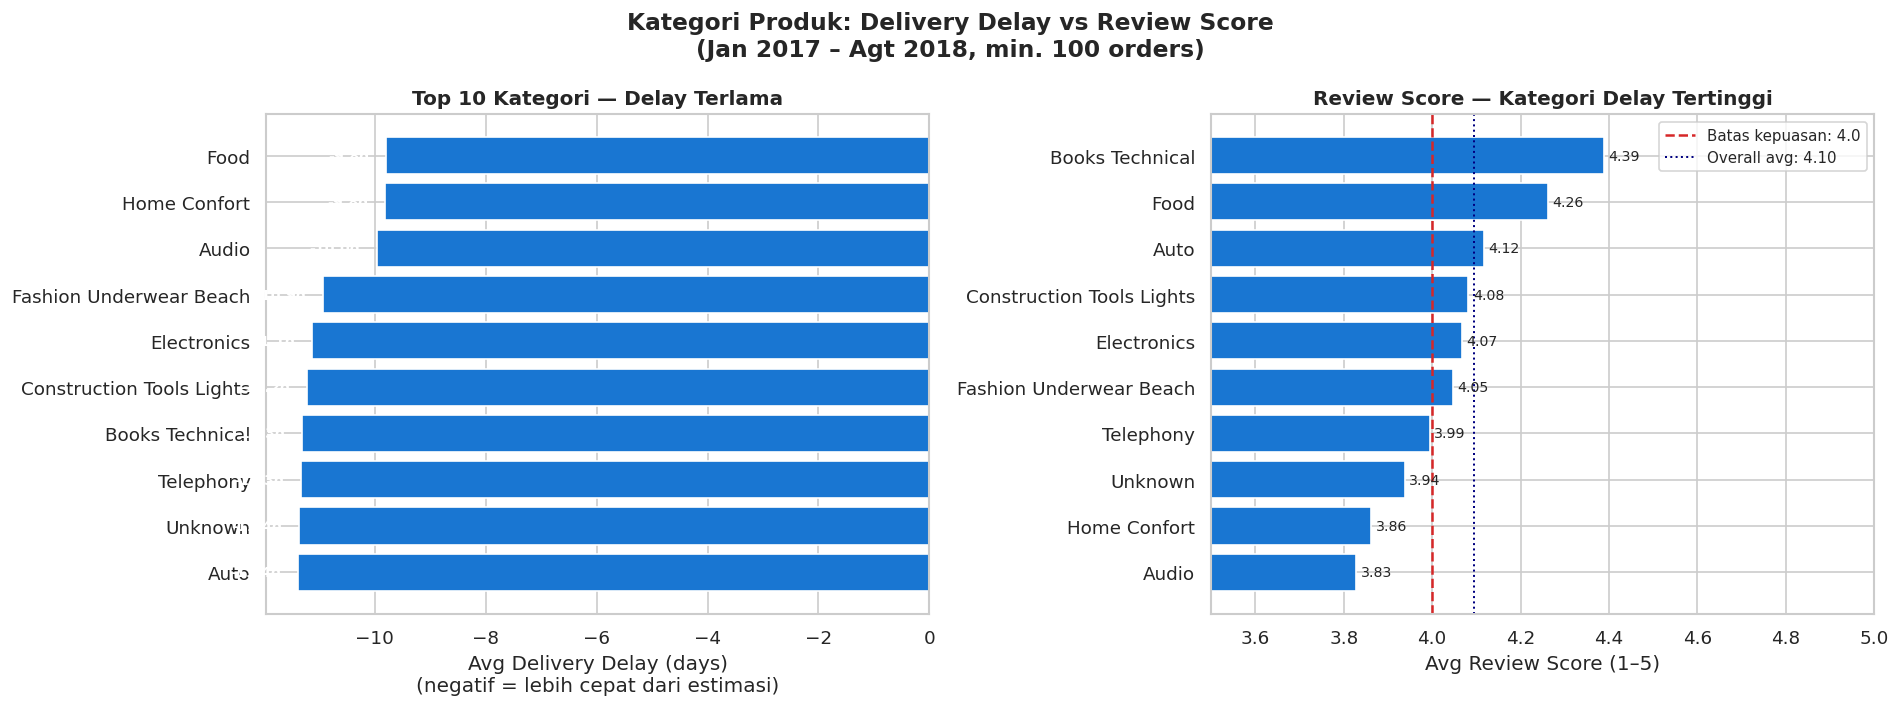

In [12]:
# Cell 12 — Viz Q1: Delay & Review
top_delay = cat_analysis.nlargest(10, 'avg_delay').copy()
top_delay['label'] = (
    top_delay['product_category_name_english']
    .str.replace('_',' ').str.title()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Kategori Produk: Delivery Delay vs Review Score\n(Jan 2017 – Agt 2018, min. 100 orders)',
    fontsize=14, fontweight='bold'
)

# Chart kiri: Delivery Delay
td   = top_delay.sort_values('avg_delay')
bars = axes[0].barh(td['label'], td['avg_delay'],
                    color='#1976D2', edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8, linestyle='--')
axes[0].set_xlabel('Avg Delivery Delay (days)\n(negatif = lebih cepat dari estimasi)')
axes[0].set_title('Top 10 Kategori — Delay Terlama', fontweight='bold')
for bar, v in zip(bars, td['avg_delay']):
    axes[0].text(bar.get_width() - 0.3,
                 bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}d', va='center', ha='right',
                 fontsize=8.5, color='white', fontweight='bold')

# Chart kanan: Review Score
td_rev  = top_delay.sort_values('avg_review')
overall = cat_analysis['avg_review'].mean()

bars2 = axes[1].barh(td_rev['label'], td_rev['avg_review'],
                      color='#1976D2', edgecolor='white')


axes[1].axvline(4.0, color='#d62728', lw=1.5, linestyle='--',
                label='Batas kepuasan: 4.0')
axes[1].axvline(overall, color='navy', lw=1.2, linestyle=':',
                label=f'Overall avg: {overall:.2f}')

axes[1].set_xlabel('Avg Review Score (1–5)')
axes[1].set_title('Review Score — Kategori Delay Tertinggi', fontweight='bold')
axes[1].set_xlim(3.5, 5.0)   # ← zoom in biar perbedaan keliatan proporsional
axes[1].legend(fontsize=9)
for bar, v in zip(bars2, td_rev['avg_review']):
    axes[1].text(bar.get_width() + 0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{v:.2f}', va='center', fontsize=8.5)


plt.tight_layout()
plt.savefig('viz_q1.png', bbox_inches='tight', dpi=150)
plt.show()

### Pertanyaan 2:
"Bagaimana tren revenue bulanan dan distribusi kontribusi masing-masing
metode pembayaran terhadap total transaksi selama periode Januari 2017 – Agustus 2018?"

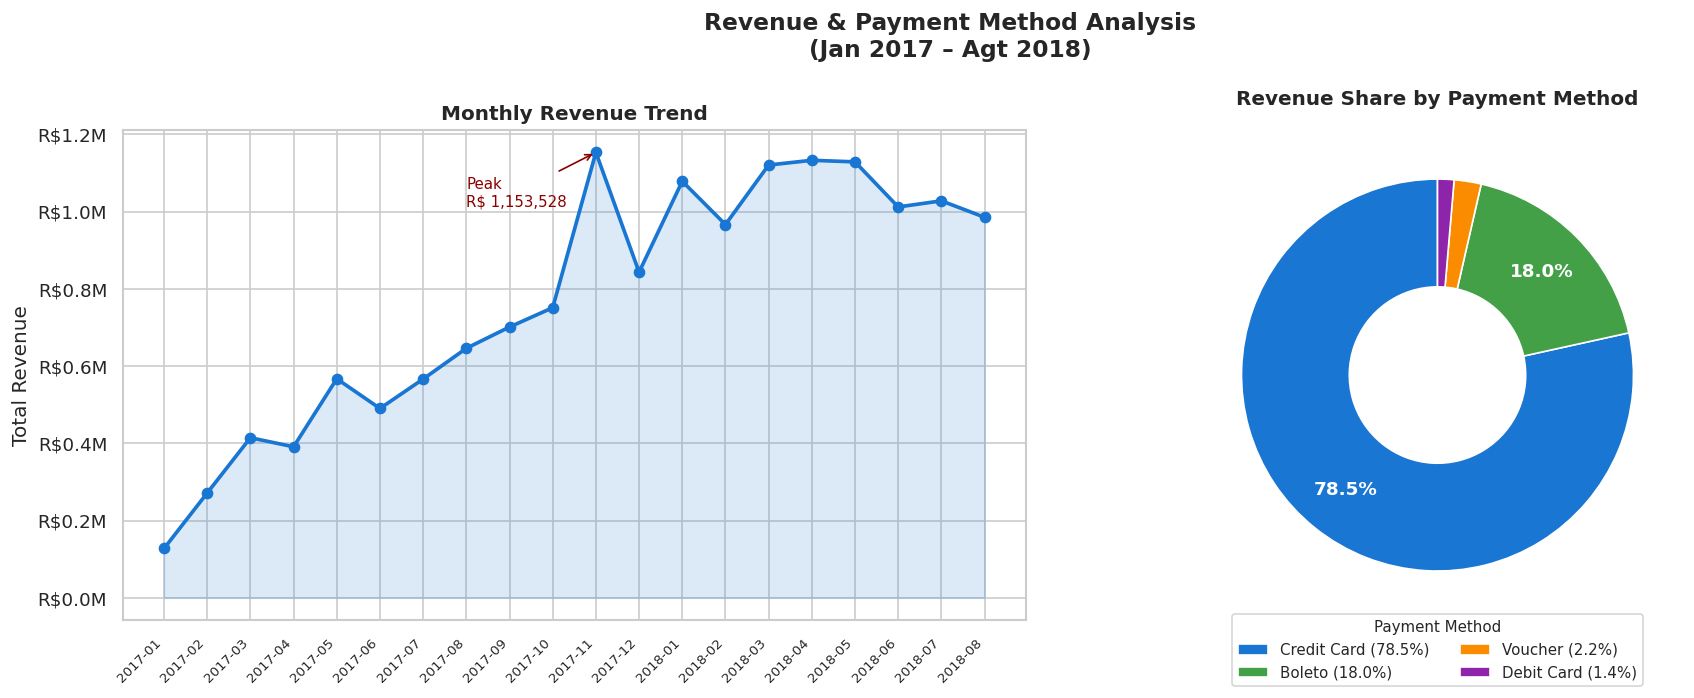

In [13]:
# Cell 13 — Viz Q2: Revenue & Payment
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Revenue & Payment Method Analysis\n(Jan 2017 – Agt 2018)',
    fontsize=14, fontweight='bold'
)

# Chart 1: Monthly Revenue
x = range(len(monthly_revenue))
axes[0].fill_between(x, monthly_revenue['total_revenue'],
                      alpha=0.15, color='#1976D2')
axes[0].plot(x, monthly_revenue['total_revenue'],
             marker='o', color='#1976D2', lw=2.2, markersize=6)
pi = monthly_revenue['total_revenue'].idxmax()
axes[0].annotate(
    f"Peak\nR$ {monthly_revenue.loc[pi,'total_revenue']:,.0f}",
    xy=(pi, monthly_revenue.loc[pi,'total_revenue']),
    xytext=(max(0, pi-3), monthly_revenue.loc[pi,'total_revenue'] * 0.88),
    arrowprops=dict(arrowstyle='->', color='darkred'),
    fontsize=9, color='darkred'
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(monthly_revenue['year_month_str'],
                         rotation=45, ha='right', fontsize=8)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'R${v/1e6:.1f}M')
)
axes[0].set_title('Monthly Revenue Trend', fontweight='bold')
axes[0].set_ylabel('Total Revenue')
axes[0].set_xlabel('')

# Chart 2: Payment
pay_colors = ['#1976D2', '#43A047', '#FB8C00', '#8E24AA']
labels     = payment_summary['payment_type'].str.replace('_', ' ').str.title()


def smart_autopct(pct):
    return f'{pct:.1f}%' if pct > 5 else ''

wedges, texts, autotexts = axes[1].pie(
    payment_summary['total_revenue'],
    labels=None,
    autopct=smart_autopct,
    colors=pay_colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55)
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
    t.set_color('white')


legend_labels = [
    f'{l} ({v:.1f}%)' for l, v in zip(
        labels,
        payment_summary['total_revenue'] /
        payment_summary['total_revenue'].sum() * 100
    )
]
axes[1].legend(
    wedges, legend_labels,
    title='Payment Method',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    fontsize=9,
    title_fontsize=9
)
axes[1].set_title('Revenue Share by Payment Method', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('viz_q2.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight:** (Opsional)
Pertanyaan 1:
- Visualisasi mengkonfirmasi kategori dengan delay terlama bukan berarti review terendah — Audio punya review terendah (3.83) di antara top 10 kategori delay terlama, sementara Books Technical justru tertinggi (4.39), artinya faktor kualitas produk lebih dominan daripada delay
- Korelasi Pearson category-level r = -0.09 tergolong lemah — delay bukan satu-satunya faktor penentu kepuasan pelanggan
- Bar chart delay group mengkonfirmasi: Very Late lebih dari 7 hari
  review anjlok ke 1.698, turun 2.5 poin dari Early delivery (4.224)

Pertanyaan 2:
- Line chart mengkonfirmasi lonjakan November 2017 sangat signifikan
  dari 751,140 BRL naik ke 1,153,528 BRL — Black Friday effect
- Donut chart menunjukkan dominasi credit card 78.45%
  yang sangat jelas — metode lain jauh tertinggal

## Analisis Lanjutan (Opsional)

Snapshot date: 2018-10-18
Total pelanggan: 93,358


,segment,count,avg_recency,avg_frequency,avg_monetary,total_monetary
0,At Risk,17463,326.37,1.04,163.06,2847588.21
4,Loyal Customers,17280,180.32,1.05,133.77,2311628.30
5,Need Attention,14213,350.06,1.00,184.45,2621587.48
7,Recent Customers,11811,107.45,1.00,162.92,1924227.27
1,Cant Lose Them,11517,500.99,1.05,167.54,1929533.81
3,Hibernating,9204,443.44,1.00,63.66,585935.94
2,Champions,6191,108.29,1.13,280.43,1736112.42
6,Potential Loyalists,5679,215.16,1.00,258.12,1465848.34


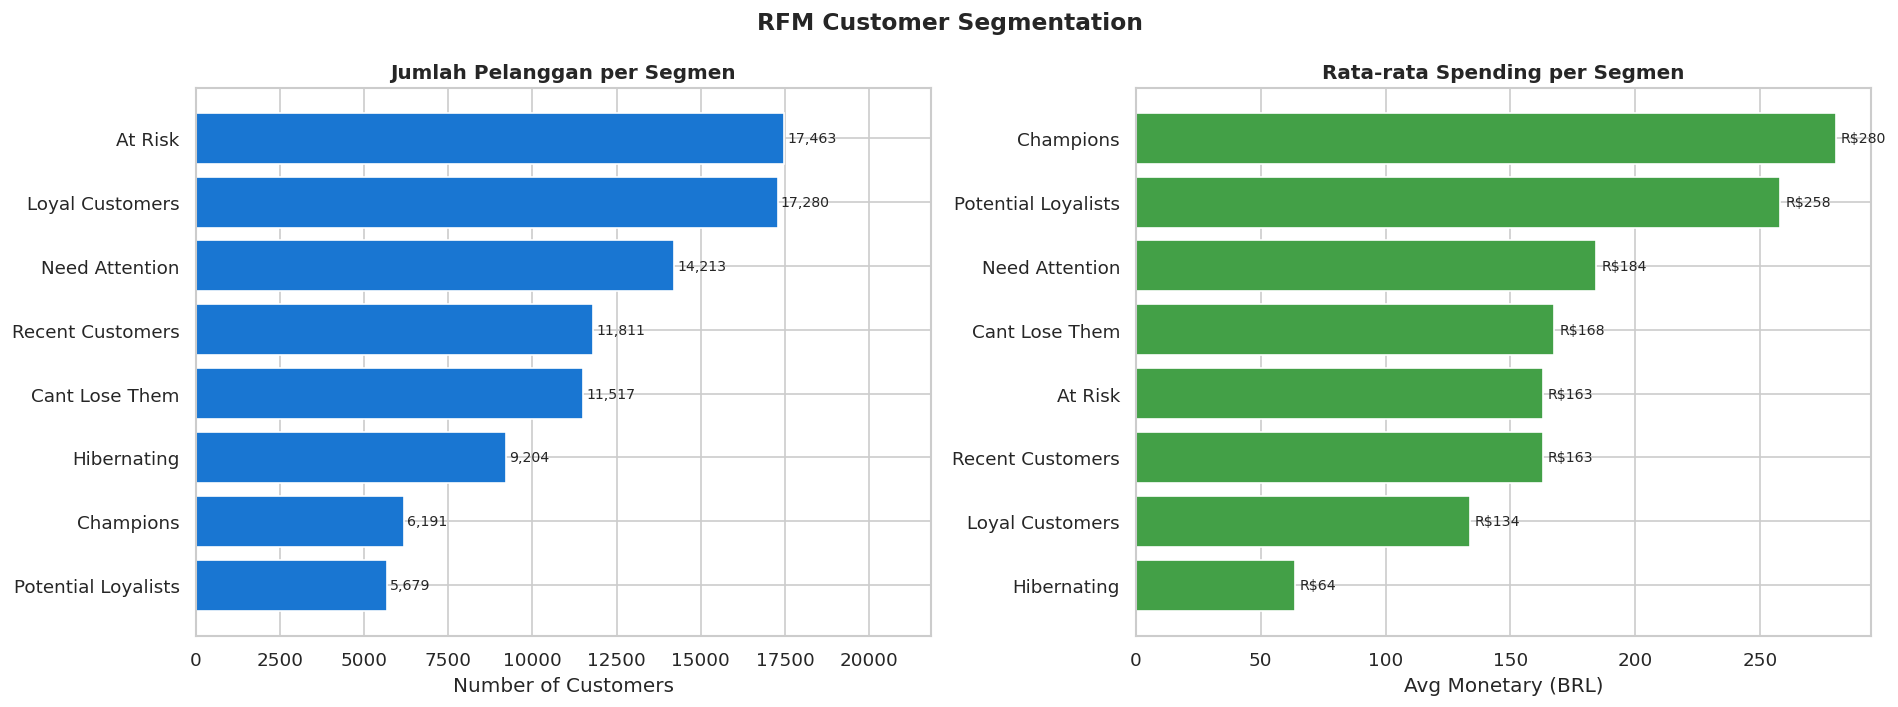

In [14]:
# Cell 14 — RFM Analysis
snapshot_date = orders_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

rfm_base = (
    orders_df[orders_df['order_status'] == 'delivered']
    .merge(customers_df[['customer_id','customer_unique_id']], on='customer_id')
    .merge(pay_per_order, on='order_id', how='left')
)

rfm = rfm_base.groupby('customer_unique_id').agg(
    recency   = ('order_purchase_timestamp',
                 lambda x: (snapshot_date - x.max()).days),
    frequency = ('order_id', 'nunique'),
    monetary  = ('total_payment', 'sum')
).reset_index()

# Scoring 1-4
rfm['R_score'] = pd.qcut(rfm['recency'], q=4,
                          labels=[4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4,
                          labels=[1,2,3,4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'], q=4,
                          labels=[1,2,3,4]).astype(int)
rfm['RFM_score'] = (rfm['R_score'].astype(str) +
                    rfm['F_score'].astype(str) +
                    rfm['M_score'].astype(str))

def segment_customer(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 3 and m >= 3:   return 'Champions'
    elif r >= 3 and f >= 3:             return 'Loyal Customers'
    elif r >= 4 and f <= 2:             return 'Recent Customers'
    elif r >= 3 and f <= 2 and m >= 3:  return 'Potential Loyalists'
    elif r == 2 and f >= 2:             return 'At Risk'
    elif r <= 2 and f >= 3:             return 'Cant Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:  return 'Hibernating'
    else:                               return 'Need Attention'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

segment_summary = rfm.groupby('segment').agg(
    count          = ('customer_unique_id', 'count'),
    avg_recency    = ('recency', 'mean'),
    avg_frequency  = ('frequency', 'mean'),
    avg_monetary   = ('monetary', 'mean'),
    total_monetary = ('monetary', 'sum')
).reset_index().sort_values('count', ascending=False)

print(f"Total pelanggan: {len(rfm):,}")
display(segment_summary.round(2))

# Viz RFM
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RFM Customer Segmentation', fontsize=14, fontweight='bold')

# Chart kiri
sc = segment_summary.sort_values('count', ascending=True)
bars_c = axes[0].barh(sc['segment'], sc['count'],
                       color='#1976D2',          # ← GANTI: single color
                       edgecolor='white')
for bar, v in zip(bars_c, sc['count']):          # ← GANTI: hapus p (%)
    axes[0].text(bar.get_width() + 100,
                 bar.get_y() + bar.get_height()/2,
                 f'{v:,}',                        # ← GANTI: hapus ({p:.1f}%)
                 va='center', fontsize=8.5)
axes[0].set_xlim(0, sc['count'].max() * 1.25)   # ← GANTI: 1.45 → 1.25
axes[0].set_title('Jumlah Pelanggan per Segmen', fontweight='bold')
axes[0].set_xlabel('Number of Customers')

# Chart kanan
sm = segment_summary.sort_values('avg_monetary', ascending=True)
bars_m = axes[1].barh(sm['segment'], sm['avg_monetary'],
                       color='#43A047',           # ← GANTI: single color
                       edgecolor='white')
for bar, v in zip(bars_m, sm['avg_monetary']):
    axes[1].text(bar.get_width() + 2,
                 bar.get_y() + bar.get_height()/2,
                 f'R\${v:,.0f}',                  # ← GANTI: R$ → R\$
                 va='center', fontsize=8.5)
axes[1].set_title('Rata-rata Spending per Segmen', fontweight='bold')
axes[1].set_xlabel('Avg Monetary (BRL)')          # ← GANTI: R$ → BRL

plt.tight_layout()
plt.savefig('viz_rfm.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight— RFM Analysis:** (Opsional)
- Analisis RFM mencakup seluruh periode dataset (hingga Oktober 2018, snapshot date: 2018-10-18) — tidak dibatasi periode Jan 2017–Agt 2018 agar recency dan frequency pelanggan terhitung secara penuh
- Total pelanggan unik yang dianalisis: 93,358
- Segmen TERBESAR: At Risk (17,463 pelanggan / 18.7%) —
  pernah aktif tapi mulai tidak kembali berbelanja
- Loyal Customers hampir sama besar: 17,280 pelanggan
- Need Attention: 14,213 pelanggan dengan avg recency
  350 hari — sudah sangat lama tidak berbelanja
- Champions: hanya 6,191 pelanggan (6.6%) namun
  avg monetary tertinggi R\$280.43 — kelompok paling berharga
- Cant Lose Them: 11,517 pelanggan dengan avg recency
  500 hari — sudah sangat lama, harus segera didekati
- Hibernating: 9,204 pelanggan dengan avg monetary
  terendah R\$63.66 — paling sulit untuk diaktifkan kembali
- Potential Loyalists: avg monetary R\$258.12 —
  hampir setara Champions, peluang upgrade terbesar
- Avg frequency hampir semua segmen sekitar 1.0x,
  loyalitas pelanggan masih sangat rendah secara keseluruhan

Top 10 States:


,customer_state,total_orders,total_revenue,avg_review,avg_delay,revenue_per_order
25,SP,40399,5755521.34,4.25,-11.02,142.47
18,RJ,12310,2046698.14,3.97,-11.68,166.26
10,MG,11319,1814317.79,4.19,-13.17,160.29
22,RS,5327,858710.29,4.19,-13.84,161.20
17,PR,4903,779319.58,4.24,-13.22,158.95
23,SC,3537,592707.68,4.13,-11.44,167.57
4,BA,3253,590949.59,3.93,-10.77,181.66
6,DF,2074,344946.06,4.14,-11.98,166.32
7,ES,1992,316690.84,4.08,-10.45,158.98
8,GO,1950,333238.10,4.10,-12.06,170.89


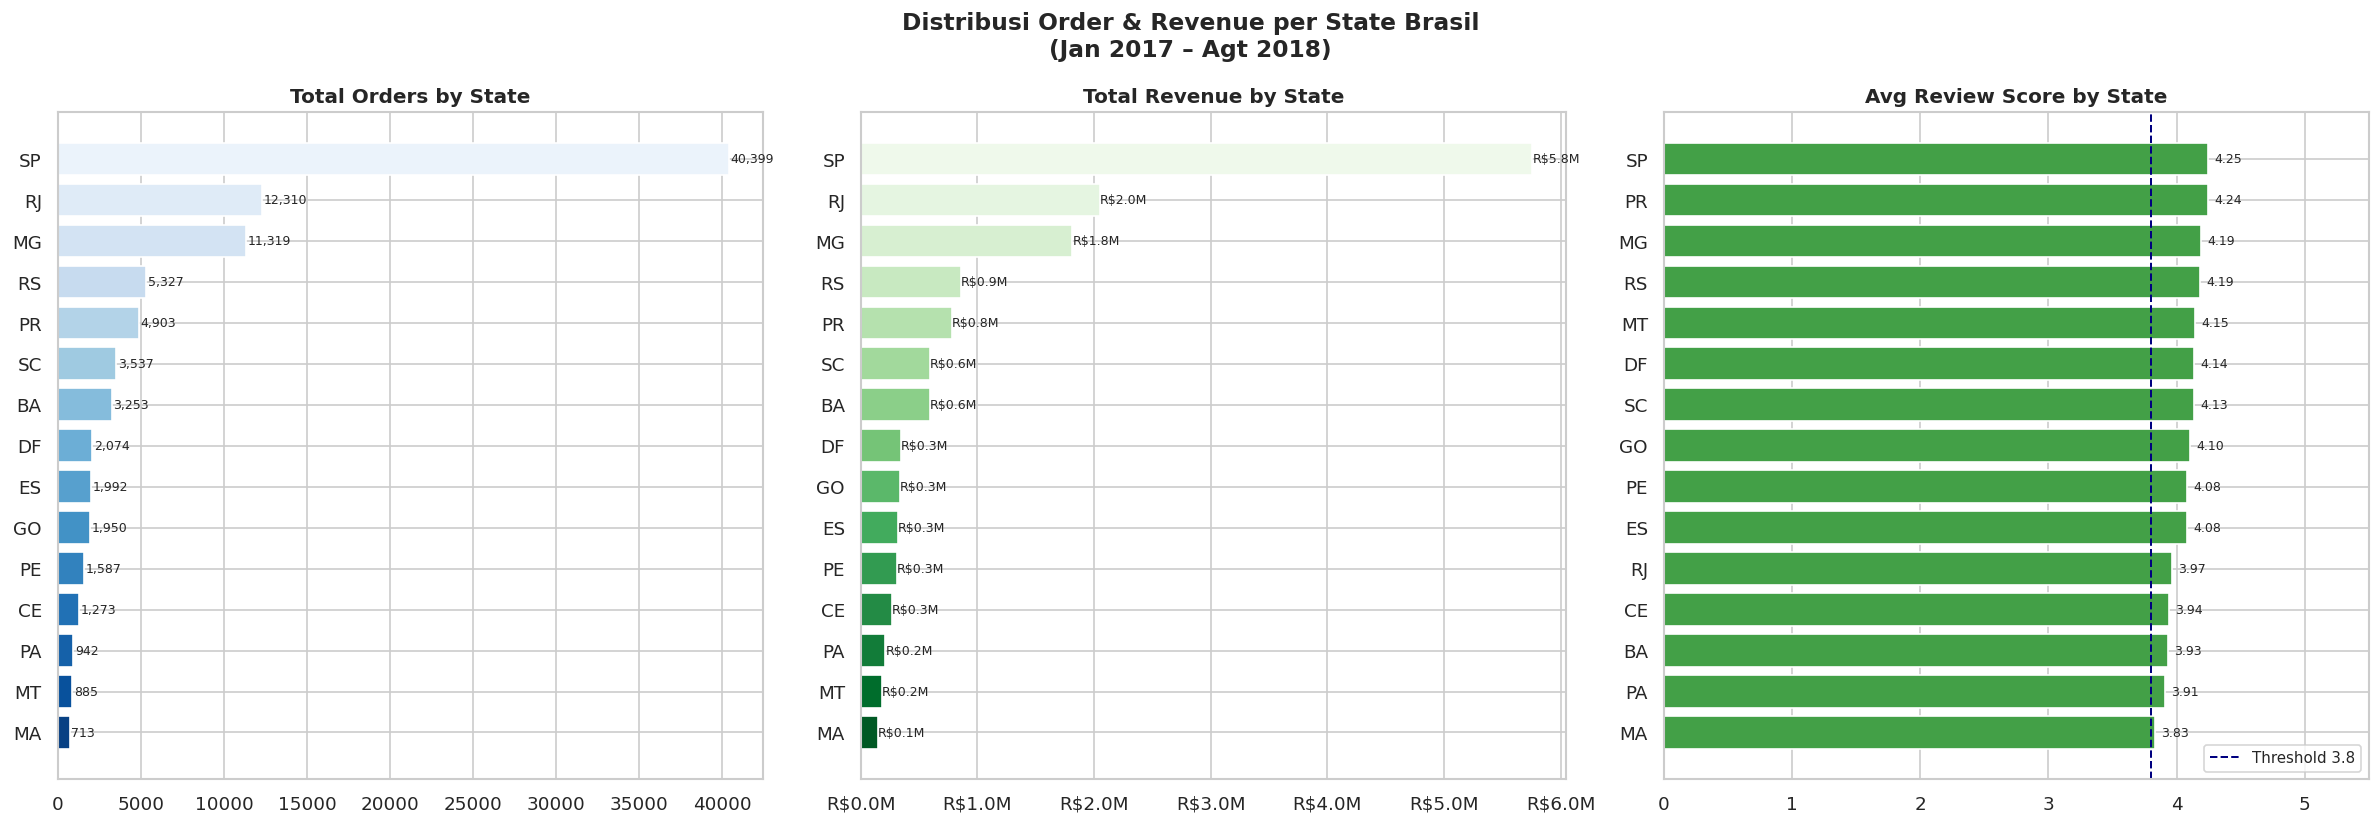

In [15]:
# Cell 15 — Geospatial Analysis
state_df = (
    main_df[['order_id','customer_state','review_score','delivery_delay_days']]
    .drop_duplicates('order_id')  # ← tambah ini
    .merge(pay_per_order, on='order_id', how='left')
    .groupby('customer_state').agg(
        total_orders  = ('order_id', 'nunique'),
        total_revenue = ('total_payment', 'sum'),  # ← pakai total_payment
        avg_review    = ('review_score', 'mean'),
        avg_delay     = ('delivery_delay_days', 'mean')
    ).reset_index()
    .sort_values('total_orders', ascending=False)
)
state_df['revenue_per_order'] = (
    state_df['total_revenue'] / state_df['total_orders']
)

print("Top 10 States:")
display(state_df.head(10).round(2))

# Viz Geospatial
top15 = state_df.head(15)
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    'Distribusi Order & Revenue per State Brasil\n(Jan 2017 – Agt 2018)',
    fontsize=14, fontweight='bold'
)

# Orders
t1 = top15.sort_values('total_orders', ascending=True)
axes[0].barh(t1['customer_state'], t1['total_orders'],
             color=sns.color_palette('Blues_r', 15), edgecolor='white')
axes[0].set_title('Total Orders by State', fontweight='bold')
for i, v in enumerate(t1['total_orders']):
    axes[0].text(v+100, i, f'{v:,}', va='center', fontsize=7.5)

# Revenue
t2 = top15.sort_values('total_revenue', ascending=True)
axes[1].barh(t2['customer_state'], t2['total_revenue'],
             color=sns.color_palette('Greens_r', 15), edgecolor='white')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'R${v/1e6:.1f}M')
)
axes[1].set_title('Total Revenue by State', fontweight='bold')
for i, v in enumerate(t2['total_revenue']):
    axes[1].text(v+1000, i, f'R${v/1e6:.1f}M', va='center', fontsize=7.5)

# Review Score
t3 = top15.sort_values('avg_review', ascending=True)
clrs = ['#d62728' if v < 3.8 else '#43A047' for v in t3['avg_review']]
axes[2].barh(t3['customer_state'], t3['avg_review'],
             color=clrs, edgecolor='white')
axes[2].axvline(3.8, color='navy', lw=1.2, linestyle='--',
                label='Threshold 3.8')
axes[2].set_xlim(0, 5.5)
axes[2].legend(fontsize=9)
axes[2].set_title('Avg Review Score by State', fontweight='bold')
for i, v in enumerate(t3['avg_review']):
    axes[2].text(v+0.05, i, f'{v:.2f}', va='center', fontsize=7.5)

plt.tight_layout()
plt.savefig('viz_geo.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight — Geospatial Analysis:**

- Sao Paulo (SP) dominasi dengan 40,399 orders dan
  revenue R\$5.75M — jauh melampaui semua state lain
- Top 3 state (SP, RJ, MG): 64,028 orders = 68.6% dari total
- State dengan review TERTINGGI: SP (4.25) dan PR (4.24) — MG menyusul dengan 4.19
- State dengan review TERENDAH: RJ (3.97) dan BA (3.93) —
  meski volume besar, kepuasan pelanggan lebih rendah
- Revenue per order TERTINGGI justru di state kecil:
  BA R\$181.66 dan SC R\$167.57 — daya beli tinggi meski volume kecil
- Avg delay TERBAIK: RS (13.84 hari lebih cepat) dan PR (13.22 hari lebih cepat) — logistik selatan Brasil efisien; PR juga mencatat review tinggi (4.24), kombinasi kecepatan dan kepuasan terbaik kedua setelah MG
- MG avg delay 13.17 hari lebih cepat dengan review 4.19 —
  kombinasi terbaik kecepatan dan kepuasan pelanggan

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:**
Terdapat korelasi negatif moderat (r = -0.23 order-level) antara
keterlambatan pengiriman dan kepuasan pelanggan. Namun temuan
menarik: semua kategori rata-rata dikirim lebih cepat dari estimasi,
sehingga review rendah pada kategori Audio (3.83) dan Home Confort (3.86) di antara top 10 delay terlama lebih disebabkan faktor kualitas produk atau ekspektasi pelanggan yang tidak terpenuhi, bukan keterlambatan pengiriman.

- **Conclusion pertanyaan 2:**
Revenue tumbuh dari 127,545 BRL (Januari 2017) dan memuncak di
1,153,528 BRL pada November 2017 (MoM +53.57% — Black Friday effect).
Sejak 2018 revenue stabil di kisaran R\$1M per bulan.
Credit card mendominasi 78.45% revenue dengan avg cicilan 3.5x,
mencerminkan perilaku belanja kredit khas konsumen Brasil.

**Rekomendasi Action Item:**
1. Investigasi kualitas produk dan deskripsi untuk kategori Audio dan Home Confort — keduanya masuk top 10 delay terlama namun review tetap rendah (3.83 dan 3.86), mengindikasikan masalah pada kualitas produk atau ekspektasi pelanggan yang tidak terpenuhi

2. Pertahankan SLA pengiriman yang sudah baik — eliminasi
   kasus Very Late lebih dari 7 hari yang membuat review
   anjlok dari 4.224 ke 1.698

3. Replikasi strategi Black Friday November ke event belanja lain seperti Cyber Monday untuk menduplikasi lonjakan revenue +53%

4. Win-back campaign prioritas untuk segmen At Risk
   (17,463 pelanggan) — tawarkan diskon personal via email
   sebelum mereka berpindah ke kompetitor

5. Upgrade Potential Loyalists (avg R\$258) menjadi Champions
   melalui program reward — monetary hampir setara
   Champions (R\$280), tinggal dorong frequency-nya

In [16]:
# Cell 16 — Export CSV untuk Dashboard

os.makedirs('dashboard', exist_ok=True)

# main_data.csv
main_df.to_csv('dashboard/main_data.csv', index=False)

# payment_data.csv
pay_monthly = (
    order_payments_clean
    .merge(orders_df[['order_id','order_purchase_timestamp',
                       'order_status']], on='order_id')
    .query("order_status == 'delivered'")
    .merge(pay_per_order, on='order_id')
)
pay_monthly['year_month'] = (
    pay_monthly['order_purchase_timestamp']
    .dt.to_period('M').astype(str)
)
pay_monthly = pay_monthly[
    (pay_monthly['order_purchase_timestamp'] >= '2017-01-01') &
    (pay_monthly['order_purchase_timestamp'] <= '2018-08-31')
]
pay_monthly.to_csv('dashboard/payment_data.csv', index=False)

# rfm_data.csv
rfm.to_csv('dashboard/rfm_data.csv', index=False)

print("✅ File dashboard berhasil disimpan!")
print("   dashboard/main_data.csv")
print("   dashboard/payment_data.csv")
print("   dashboard/rfm_data.csv")

✅ File dashboard berhasil disimpan!
   dashboard/main_data.csv
   dashboard/payment_data.csv
   dashboard/rfm_data.csv
